In [2]:
import isodata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [32]:
DATA_DIR = Path("/home/sean/code/study-hard/controls/online_optimization/project/datasets")
ALL_LMPS_FILENAME = DATA_DIR / "july_12_2023_all_lmps.csv"
YEAR_LMP_FILENAME = "lmp_for_year.csv"

In [4]:
iso = isodata.get_iso("caiso")()

In [5]:
iso.get_latest_fuel_mix()

ISO: California ISO
Total Production: 23856 MW 
Time: 2023-12-16 16:00:00-08:00 
+-------------+-------+-----------+
| Fuel        |    MW |   Percent |
|-------------+-------+-----------|
| Natural Gas | 10900 |      45.7 |
| Imports     |  3730 |      15.6 |
| Batteries   |  2557 |      10.7 |
| Solar       |  2223 |       9.3 |
| Large Hydro |  1241 |       5.2 |
| Nuclear     |  1120 |       4.7 |
| Wind        |   766 |       3.2 |
| Geothermal  |   587 |       2.5 |
| Biomass     |   323 |       1.4 |
| Small hydro |   238 |       1   |
| Biogas      |   171 |       0.7 |
| Coal        |     0 |       0   |
| Other       |     0 |       0   |
+-------------+-------+-----------+

In [6]:
regions = [
    "SANRAFL_1_N007",
    "SPRINGVL_6_N008",
    "LYTNVLLE_6_N001"
]

In [7]:
day_of_interest = "2023-07-12"

In [9]:
lmps = iso.get_historical_lmp(
    day_of_interest,
    isodata.Markets.REAL_TIME_15_MIN, locations=regions)

In [8]:
def batched(it, n):
    gen = (i for i in it)
    while True:
        batch = []
        for _ in range(n):
            try:
                batch.append(next(gen))
            except StopIteration:
                yield batch
                return
        yield batch


## Load LMPs for all nodes

In [6]:
all_nodes = iso.get_pnodes()["PNode ID"].tolist()

In [9]:
lmps_all = []
for n in batched(all_nodes, 100):
    lmps_all.append(iso.get_historical_lmp(
        day_of_interest,
        isodata.Markets.REAL_TIME_15_MIN, locations=n, verbose=True
    ))
lmps_df = pd.concat(lmps_all)

http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_RTPD_LMP&version=3&startdatetime=20230712T07:00-0000&enddatetime=20230713T07:00-0000&market_run_id=RTPD&node=DOUBLEC_1_B1,CAYETNO_2_N003,SONOFR2_7_B1,JESSUP_1_GN001,SANBRDNO_6_N017,GARNET_7_N009,HMBLTBY_6_B1,2C559EQ2_7_N001,GARNET_7_N006,LECEFST1_7_B1,BERNARDO_6_N001,BUENAVT_2_N006,COLSTJT_1_B1,Q885C2_7_N001,ASTORIA1_7_N001,GOULD_2_B1,STOCKDL_2_N002,ALTA1G_7_B1,TOT210S1_7_N002,GARNET_7_N013,Q678C2_7_N001,BIGSKGN4_7_N001,SUNRAY2_7_N001,SUNGEN5G_7_N001,SANRAMON_2_N023,GLDHLGNC_7_N001,MOORPARK_6_N001,MESQSLR2_7_N002,SPRINGVL_2_N039,ETIWANDA_6_N025,BULLARD_1_N001,CENTERS_6_N009,ETIWANDA_6_N011,SANDBAR_7_B1,MILPITAS_1_N001,RECTOR_6_N001,TOREYPNS_6_N001,PADUA_2_N019,GATES_6_B1,GARNET_1_N106,SCLARA_2_B1,SCLARA_6_N008,CUYAMAGN_7_N001,STG1SGN_7_N001,WISHON2_7_B3,APPLEHL_1_N004,POTTRVLY_7_N003,KERCK1G3_7_B1,ALAMT2G_7_B1,RECTOR_6_N007,ELKHRN_7_N003,BOWMNTAP_6_B1,ATHOS_7_CN13,ARLNG1MV_7_N002,CRIMSN_7_CN4,DSRTSN_7_N001,Q965C2_7_

http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_RTPD_LMP&version=3&startdatetime=20230712T07:00-0000&enddatetime=20230713T07:00-0000&market_run_id=RTPD&node=DELTAPMP_2_N008,ETIWANDA_2_N001,SUNRAYGN_7_N001,TAP806_1_B1,RENWIND_1_N001,LITLRKC1_7_N002,SANMRCOS_6_N001,HARRIS_6_N001,CAMINO_2_N001,UNIT7GT_7_N001,S632_7_N001,EASTGATE_6_N004,Q6081_7_N001,FNTRG1_7_N001,INYOKERN_1_N001,MCARTHR_6_N002,ETIWANDA_2_N109,DUCORGN4_7_N001,CSTRVLLE_1_N005,COVERD_7_N005,JOHANNA_2_N013,WILLWCRK_6_N003,BIGSKGN7_7_N001,SCHINDLR_1_N030,Q137GN1_7_N001,RANDSBG_7_N002,VASCJCT_6_B1,SUNGEN6G_7_N001,EAGLEMTN_2_N001,KERNPWR_1_N002,KERCK1G1_7_B2,VALLEYSC_5_B1,BPFFD_1_N002,SANBRN_7_N001,SPRINGVL_6_N002,KONOCTI6_6_N001,BLM W_2_COSBT1GN,VINCENT_2_N101,TULARE60_7_CN2,JOANEC_7_N002,SANBRN_7_GN2SB3,CENTPD_7_N004,SUNGEN3G_7_N005,SUNGEN3G_7_N002,LODISTG_7_B1,WDLNDBM_1_B1,KERNOIL_1_B1,S636_7_N001,OXMOUNTN_6_N001,DAVIS_1_N018,DELSURC1_7_N005,CONTROLX_1_N003,MIRALOMA_6_N207,GRIDLEY_6_N004,MIDLFORK_2_B1,GO

http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_RTPD_LMP&version=3&startdatetime=20230712T07:00-0000&enddatetime=20230713T07:00-0000&market_run_id=RTPD&node=BELLPGE_1_N001,BRUNSWCK_1_N003,PRAXAIR_1_GN001,MONROE_1_N001,4C687C2_7_N001,JVENTER_2_N001,SCLARA_2_N114,VALLEYSC_1_N013,MONLTS12_7_N006,STKTONA_1_LN001,ELCRRTO_1_N001,PANAERO_1_N001,PLOALTO_1_N001,GASLRGN_7_N001,SNJOSEB_1_N001,MESARIM_6_GN001,MONLTS12_7_N005,Q607GEN_7_N002,DAWNLS_7_N001,ALTA6E2_7_N002,MARTINC_1_B1,PORTRDGC_7_N009,GARNET_7_N003,MILLBRAE_1_N007,LARKIN12_7_LN001,CLLCTR2B_7_N001,VICTOR_1_N001,ALTMMDW_2_N001,SUNGEN3G_7_N001,GRNVALY_1_N035,SANRAFL_1_N006,BRDWAYB3_7_B1,TRABUCO_1_N001,Q1032C2_7_N004,SHADOWR_1_N015,LNCSTRC1_7_N004,IENERGY_7_B1,BIGSK230_2_N024,TOT545L_7_N001,SONOMA_1_N077,GRAPEVNE_6_GN001,MILPITAS_1_N008,SJ1B12_7_N003,Q137GN4_7_N001,Q137GN3_7_N001,SUWSOFGN_7_N001,CABRILLO_6_N011,RIOHONDO_6_N004,POINTLMA_6_N021,SRMS2GN_7_N001,BP21Z_1_N002,WSTWND_7_N001,ARLNG2MV_7_N001,PEASE_7_N001,PSQU

In [14]:
lmps_df.to_csv(ALL_LMPS_FILENAME)

## Load from CSV

In [12]:
lmps_df = pd.read_csv(ALL_LMPS_FILENAME)

In [13]:
lmps_df = lmps_df.set_index("Time")

In [14]:
mean_lmps = lmps_df.groupby("Location").apply(lambda df: df["LMP"].mean())

In [15]:
extreme_locations = mean_lmps.index[[
    mean_lmps.argmin(),
    mean_lmps.argmax(),
    np.argwhere(mean_lmps == mean_lmps.median())[0][0]
]]



In [16]:
extreme_lmps = lmps_df[lmps_df["Location"].isin(extreme_locations)].pivot(columns="Location")

In [17]:
extreme_lmps

Unnamed: 0                                 \
Location                  AVENAL_6_GN001 CATALYST_7_N002 PTHLGEN_7_N002   
Time                                                                      
2023-07-12 00:00:00-07:00              3              10             65   
2023-07-12 00:15:00-07:00            103             108            165   
2023-07-12 00:30:00-07:00            203             206            265   
2023-07-12 00:45:00-07:00            303             304            365   
2023-07-12 01:00:00-07:00            403             402            465   
...                                  ...             ...            ...   
2023-07-12 22:45:00-07:00           9103            8928           9165   
2023-07-12 23:00:00-07:00           9203            9026           9265   
2023-07-12 23:15:00-07:00           9303            9124           9365   
2023-07-12 23:30:00-07:00           9403            9222           9465   
2023-07-12 23:45:00-07:00           9503            9320           9565   

                                     Market                    \
Location                     AVENAL_6_GN001   CATALYST_7_N002   
Time                                                            
2023-07-12 00:00:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 00:15:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 00:30:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 00:45:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 01:00:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
...                                     ...               ...   
2023-07-12 22:45:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 23:00:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 23:15:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 23:30:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   
2023-07-12 23:45:00-07:00  REAL_TIME_15_MIN  REAL_TIME_15_MIN   

                                             Location Type                  \
Location                     PTHLGEN_7_N002 AVENAL_6_GN001 CATALYST_7_N002   
Time                                                                         
2023-07-12 00:00:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 00:15:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 00:30:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 00:45:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 01:00:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
...                                     ...            ...             ...   
2023-07-12 22:45:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 23:00:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 23:15:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 23:30:00-07:00  REAL_TIME_15_MIN            NaN             NaN   
2023-07-12 23:45:00-07:00  REAL_TIME_15_MIN            NaN             NaN   

                                                    LMP  ...                 \
Location                  PTHLGEN_7_N002 AVENAL_6_GN001  ... PTHLGEN_7_N002   
Time                                                     ...                  
2023-07-12 00:00:00-07:00            NaN       52.70473  ...       50.45428   
2023-07-12 00:15:00-07:00            NaN       48.24218  ...       46.09336   
2023-07-12 00:30:00-07:00            NaN       41.69517  ...       39.77648   
2023-07-12 00:45:00-07:00            NaN       38.31673  ...       36.71906   
2023-07-12 01:00:00-07:00            NaN       46.89000  ...       46.89000   
...                                  ...            ...  ...            ...   
2023-07-12 22:45:00-07:00            NaN       57.36000  ...       57.36000   
2023-07-12 23:00:00-07:00            NaN       58.75852  ...       57.14602   
2023-07-12 23:15:00-07:00            NaN       52.14134  ...       50.81314   
2023-07-12 23:30:00-07:00  

In [18]:
column_to_plot = ["LMP", "Energy", "Congestion", "Loss"]

In [19]:
extreme_lmps["LMP"].mean()

Location
AVENAL_6_GN001    -21.078853
CATALYST_7_N002    95.891744
PTHLGEN_7_N002     45.032359
dtype: float64

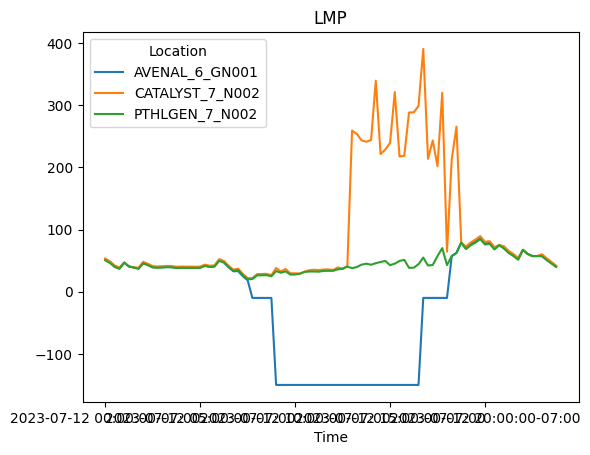

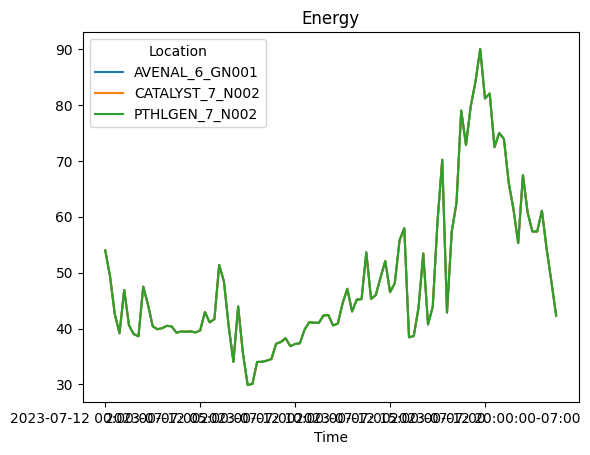

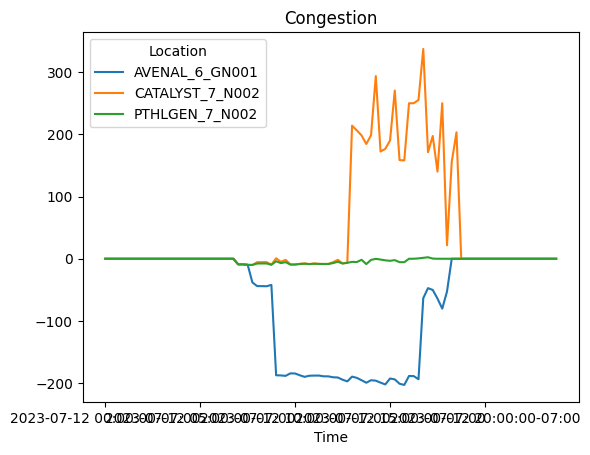

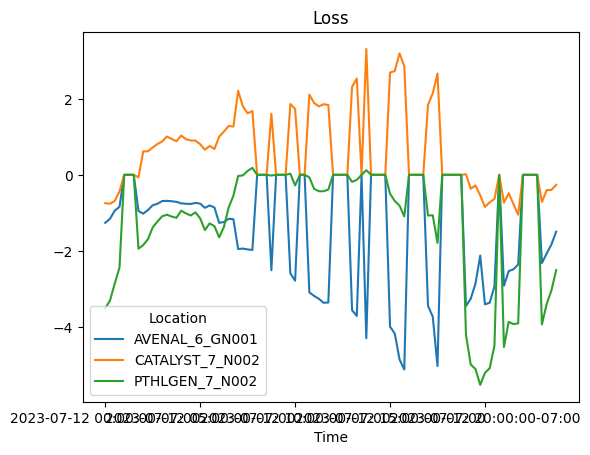

In [20]:
for col in column_to_plot:
    extreme_lmps[col].plot(title=col)

## How much do profits vary between days?

In [21]:
import datetime

In [22]:
jan1 = datetime.datetime(2023, 1, 1)
end_day = datetime.datetime(2023, 12, 15)

In [23]:
nodes_of_interest = extreme_locations.to_list()
nodes_of_interest.append("SANRAFL_1_N007")

In [28]:
date = jan1
lmp_for_year = []
while date < end_day:
    date_str = date.strftime("%Y-%m-%d")
    print("Loading:", date_str)
    lmp_day = iso.get_historical_lmp(
        date_str, isodata.Markets.REAL_TIME_15_MIN, 
        locations=nodes_of_interest, sleep=2
    )
    lmp_for_year.append(lmp_day)
    date += datetime.timedelta(days=1)
lmp_for_year = pd.concat(lmp_for_year)

Loading: 2023-01-01
Loading: 2023-01-02
Loading: 2023-01-03
Loading: 2023-01-04
Loading: 2023-01-05
Loading: 2023-01-06
Loading: 2023-01-07
Loading: 2023-01-08
Loading: 2023-01-09
Loading: 2023-01-10
Loading: 2023-01-11
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-01-12
Loading: 2023-01-13
Loading: 2023-01-14
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-01-15
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-01-16
Loading: 2023-01-17
Loading: 2023-01-18
Loading: 2023-01-19
Loading: 2023-01-20
Loading: 2023-01-21
Loading: 2023-01-22
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-01-23
Loading: 2023-01-24
Loading: 2023-01-25
Loading: 2023-01-26
Loading: 2023-01-27
Loading: 2023-01-28
Loading: 2023-01-29
Loading: 2023-01-30
Loading: 2023-01-31
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-02-01
Loading: 2023-02-02
Loading: 2023-02-03
Loading: 2023-02-04
Loading: 2023-02-05


Loading: 2023-11-30
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-01
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-02
Loading: 2023-12-03
Loading: 2023-12-04
Loading: 2023-12-05
Loading: 2023-12-06
Loading: 2023-12-07
Loading: 2023-12-08
Loading: 2023-12-09
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-10
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-11
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-12
Failed to get data from CAISO. Error: 429
Retrying 1...
Loading: 2023-12-13
Loading: 2023-12-14
Failed to get data from CAISO. Error: 429
Retrying 1...


In [29]:
len(lmp_for_year)

133632

In [31]:
lmp_for_year.to_csv(DATA_DIR / YEAR_LMP_FILENAME)

In [87]:
end_day

datetime.datetime(2023, 12, 16, 16, 57, 26, 385491)

## Visualizing fuel mix

In [76]:
fuel_mix = iso.get_historical_fuel_mix(day_of_interest, verbose=True)
fuel_mix = fuel_mix.set_index("Time")

Fetching URL:  https://www.caiso.com/outlook/SP/History/20230712/fuelsource.csv


In [77]:
sorted_by_abs = fuel_mix.abs().sum().sort_values(ascending=False)
battery_index = sorted_by_abs.index.tolist().index("Batteries")
highest_sources = sorted_by_abs.index[:battery_index + 1]

<Axes: xlabel='Time'>

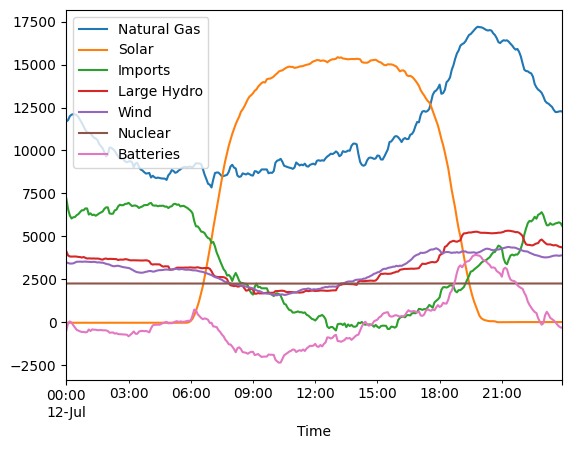

In [80]:
fuel_mix.loc[:, highest_sources].plot()